In [2]:
from pathlib import Path
import sys
import polars as pl

MODELS_ROOT = Path("/mnt/filesystem-test/nmr/models")
SCRIPT_ROOT = Path("/mnt/filesystem-test/nmr/scripts")

sys.path.insert(0, str(MODELS_ROOT))
sys.path.insert(0, str(MODELS_ROOT / "NMRPeak"))
sys.path.insert(0, str(SCRIPT_ROOT))

### NMRPeak - Exploration

In [2]:
import polars as pl
import json
import lmdb


In [ ]:
nmrpeak_data = pl.read_parquet("/mnt/filesystem-test/nmr/models/NMRPeak/data/NMRexp_10to24_1_1004.parquet",)
print(nmrpeak_data)

shape: (3_372_987, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Filename  ┆ SMILES    ┆ Page_in_f ┆ Page_in_f ┆ … ┆ NMR_proce ┆ Atom_numb ┆ Atom_numb ┆ Atom_num │
│ ---       ┆ ---       ┆ ile_mol   ┆ ile_para  ┆   ┆ ssed      ┆ er        ┆ er_diff_e ┆ ber_abst │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ nv        ┆ ract     │
│           ┆           ┆ f64       ┆ i64       ┆   ┆ str       ┆ i64       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ i64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 10.1021_a ┆ [Si](CC)( ┆ 15.0      ┆ 15        ┆ … ┆ [(180.0,  ┆ 22        ┆ 18        ┆ 17.0     │
│ cs.orglet ┆ CC)(CC)/C ┆           ┆           ┆   ┆ 'd',      ┆           ┆           ┆          │
│ t.3c00718 ┆ (F)=C(/Cc ┆           ┆           ┆   ┆ 300.8),   ┆   

In [9]:
from nmrpeak.data import LMDBDataset

lmdb_path = (
"/mnt/filesystem-test/nmr/models/NMRPeak/data/NMRexp/lmdb_dataset/test_100sample.lmdb"
)

dataset = LMDBDataset(str(lmdb_path))
print(len(dataset))
sample = dataset[0]
print(sample.keys())
display(sample)
print(sample["c_nmr_peaks"][0].keys())
print(sample["h_nmr_peaks"][0].keys())

100
dict_keys(['smiles', 'smiles_canonical', 'nmr_frequency', 'nmr_solvent', 'molecular_formula', 'c_nmr_peaks', 'atoms', 'coordinates', 'h_nmr_peaks'])


{'smiles': 'CCCCOC(/C=C/c1sc(-c2ncc(C)cc2)cc1)=O',
 'smiles_canonical': 'CCCCOC(=O)/C=C/c1ccc(-c2ccc(C)cn2)s1',
 'nmr_frequency': '151 MHz',
 'nmr_solvent': 'CDCl3',
 'molecular_formula': 'C17H19NO2S',
 'c_nmr_peaks': [{'delta (ppm)': 167.0},
  {'delta (ppm)': 150.1},
  {'delta (ppm)': 149.2},
  {'delta (ppm)': 147.7},
  {'delta (ppm)': 140.4},
  {'delta (ppm)': 137.3},
  {'delta (ppm)': 137.2},
  {'delta (ppm)': 132.5},
  {'delta (ppm)': 132.0},
  {'delta (ppm)': 124.6},
  {'delta (ppm)': 118.7},
  {'delta (ppm)': 117.3},
  {'delta (ppm)': 64.5},
  {'delta (ppm)': 30.9},
  {'delta (ppm)': 19.3},
  {'delta (ppm)': 18.4},
  {'delta (ppm)': 13.8}],
 'atoms': ['C',
  'C',
  'C',
  'C',
  'O',
  'C',
  'O',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'C',
  'N',
  'S',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H'],
 'coordinates': array([[-7.6268935e+00, -1.1847308e+00,

dict_keys(['delta (ppm)'])
dict_keys(['category', 'centroid', 'delta', 'j_values', 'nH', 'rangeMax', 'rangeMin'])


In [3]:
from pathlib import Path
from nmrpeak.data import LMDBDataset

root = Path(
    "/mnt/filesystem-test/nmr/models/NMRPeak/data/NMRexp/lmdb_dataset"
)

for name in (
    "train.lmdb",
    "valid.lmdb",
    "test.lmdb",
    "all.lmdb",
    "train.small.lmdb",
):
    ds = LMDBDataset(str(root / name))
    print(name, len(ds))

fused_multi_tensor is not installed corrected
fused_rounding is not installed corrected
fused_layer_norm is not installed corrected
fused_rms_norm is not installed corrected
fused_softmax is not installed corrected
train.lmdb 920796
valid.lmdb 48463
test.lmdb 107696
all.lmdb 1076955
train.small.lmdb 1280


In [8]:
from nmrpeak.data import LMDBDataset

lmdb_path = (
"/mnt/filesystem-test/nmr/models/NMRPeak/data/MST_NMR/lmdb_dataset/valid.lmdb"
)

dataset = LMDBDataset(str(lmdb_path))
print(len(dataset))
sample = dataset[0]
print(sample.keys())
display(sample)
print(sample["c_nmr_peaks"][0].keys())
print(sample["h_nmr_peaks"][0].keys())

35747
dict_keys(['smiles', 'smiles_canonical', 'molecular_formula', 'c_nmr_peaks', 'h_nmr_peaks', 'atoms', 'coordinates'])


{'smiles': 'CCOC(=O)C(F)(F)c1ccc(Oc2cncc3sc(C(=O)NC)cc23)cc1',
 'smiles_canonical': 'CCOC(=O)C(F)(F)c1ccc(Oc2cncc3sc(C(=O)NC)cc23)cc1',
 'molecular_formula': 'C19H16F2N2O4S',
 'c_nmr_peaks': [{'delta (ppm)': 165.51090766478632,
   'integral': 0.0009470498332574,
   'intensity': 0.0501752380891228,
   'width (ppm)': 0.011999404481894},
  {'delta (ppm)': 163.95816540852897,
   'integral': 0.0002364640123806,
   'intensity': 0.0125365513395442,
   'width (ppm)': 0.011999404481894},
  {'delta (ppm)': 163.67775343802575,
   'integral': 0.0004734011755103,
   'intensity': 0.0250823216316257,
   'width (ppm)': 0.011999404481894},
  {'delta (ppm)': 163.39543478511996,
   'integral': 0.0002365400528538,
   'intensity': 0.012541311375829,
   'width (ppm)': 0.011999404481894},
  {'delta (ppm)': 157.94747620724965,
   'integral': 0.00094704827885,
   'intensity': 0.0501751025710415,
   'width (ppm)': 0.011999404481894},
  {'delta (ppm)': 150.86283948487164,
   'integral': 0.0009470560362686,
   'i

dict_keys(['delta (ppm)', 'integral', 'intensity', 'width (ppm)'])
dict_keys(['category', 'centroid', 'delta', 'j_values', 'nH', 'rangeMax', 'rangeMin'])


In [11]:
from pathlib import Path
from nmrpeak.data import LMDBDataset

root = Path(
    "/mnt/filesystem-test/nmr/models/NMRPeak/data/MST_NMR/lmdb_dataset"
)
sum_ = 0
for name in (
    "train.lmdb",
    "valid.lmdb",
    "test.lmdb",
):
    ds = LMDBDataset(str(root / name))
    print(name, len(ds))
    sum_ += len(ds)
print("total", sum_)

train.lmdb 679186
valid.lmdb 35747
test.lmdb 79437
total 794370


##### Analisi Multiplcity

In [19]:
from collections import Counter
import pickle
import lmdb
from tqdm import tqdm

env = lmdb.open(
    "/mnt/filesystem-test/nmr/models/NMRPeak/data/NMRexp/lmdb_dataset/all.lmdb",
    subdir=False,
    readonly=True,
    lock=False,
    readahead=False,
    meminit=False,
)

counter = Counter()

with env.begin() as txn:
    cursor = txn.cursor()
    for _, value in tqdm(cursor, desc="Processing samples", total=env.stat()["entries"]):
        sample = pickle.loads(value)
        h_peaks = sample["h_nmr_peaks"]
        if h_peaks:
            for peak in h_peaks:
                counter[peak["category"]] += 1
print(counter)
print(f"Total peaks: {sum(counter.values())}")
for category, count in counter.most_common():
    # print as percentage of total peaks sorted by frequency
    percentage = (count / sum(counter.values())) * 100
    print(f"Category: {category}, Count: {count}, Percentage: {percentage:.2f}%")

Processing samples:   0%|          | 0/1076955 [00:00<?, ?it/s]

Processing samples: 100%|██████████| 1076955/1076955 [00:11<00:00, 91482.56it/s]

Counter({'m': 2643805, 'd': 1708097, 's': 1698442, 't': 697095, 'dd': 567224, 'q': 119517, 'ddd': 93777, 'dt': 81246, 'brs': 77988, 'td': 76548, 'br': 23928, 'p': 18577, 'dq': 17826, 'ddt': 16251, 'tt': 15537, 'hept': 11922, 'qd': 8453, 'dddd': 7263, 'dtd': 4738, 'tdd': 3219, 'brd': 3076, 'app t': 2533, 'hex': 1983, 'qt': 1688, 'tq': 1420, 'dtt': 1410, 'dp': 1382, 'app d': 1354, 'ddq': 1209, 'brt': 1068, 'dqd': 971, 'ABq': 759, 'pd': 720, 'AB': 627, 'app q': 605, 'app td': 534, 'app s': 482, 'app dt': 439, 'dddt': 417, 'qdd': 399, 'tdt': 336, 'app dd': 306, 'dh': 261, 'ttd': 242, 'pt': 160, 'app dq': 153, 'brq': 152, 'ddtd': 145, 'spt': 142, 'dtdd': 123, 'dtq': 121, 'brdd': 117, 'tp': 116, 'ddp': 114, 'dqt': 108, "AA'BB'": 68, 'ABX': 57})
Total peaks: 7917250
Category: m, Count: 2643805, Percentage: 33.39%
Category: d, Count: 1708097, Percentage: 21.57%
Category: s, Count: 1698442, Percentage: 21.45%
Category: t, Count: 697095, Percentage: 8.80%
Category: dd, Count: 567224, Percentage:

In [2]:
from collections import Counter
import pickle
import lmdb
from tqdm import tqdm

env = lmdb.open(
    "/mnt/filesystem-test/nmr/models/NMRPeak/data/MST_NMR/lmdb_dataset/train.lmdb",
    subdir=False,
    readonly=True,
    lock=False,
    readahead=False,
    meminit=False,
)

counter = Counter()

with env.begin() as txn:
    cursor = txn.cursor()
    for _, value in tqdm(cursor, desc="Processing samples", total=env.stat()["entries"]):
        sample = pickle.loads(value)
        h_peaks = sample["h_nmr_peaks"]
        if h_peaks:
            for peak in h_peaks:
                counter[peak["category"]] += 1
print(counter)
print(f"Total peaks: {sum(counter.values())}")
for category, count in counter.most_common():
    # print as percentage of total peaks sorted by frequency
    percentage = (count / sum(counter.values())) * 100
    print(f"Category: {category}, Count: {count}, Percentage: {percentage:.2f}%")

Processing samples:   0%|          | 0/679186 [00:00<?, ?it/s]

Processing samples: 100%|██████████| 679186/679186 [06:05<00:00, 1860.56it/s]

Counter({'m': 1681033, 's': 983287, 'd': 906286, 'dd': 641130, 't': 501521, 'ddd': 330841, 'dt': 220354, 'ddt': 133771, 'q': 122361, 'td': 117859, 'dddd': 104648, 'dq': 84153, 'tt': 82910, 'p': 74364, 'dtd': 44506, 'dp': 29966, 'ddq': 17730, 'dtt': 17322, 'qd': 16578, 'hept': 14350, 'qt': 14241, 'h': 12630, 'dqd': 11566, 'dddt': 11389, 'pd': 9487, 'tdd': 9111, 'tq': 8736, 'ddtd': 6125, 'ddddd': 6090, 'dtdd': 4991, 'pt': 4305, 'tdt': 3929, 'ttd': 3579, 'tp': 3017, 'dh': 2893, 'qdd': 2705, 'ddp': 2130, 'dtq': 1936, 'tddd': 1883, 'dddq': 1448, 'qq': 1390, 'dqt': 1326, 'ddtt': 1212, 'dhept': 1198, 'pq': 1111, 'tdq': 1059, 'dtdt': 1055, 'heptd': 948, 'hd': 863, 'ddddt': 746, 'ttt': 675, 'dpd': 664, 'qdt': 611, 'ttq': 565, 'th': 448, 'dddp': 401, 'dqdd': 386, 'qtd': 373, 'pdd': 370, 'ddtdd': 329, 'ddtq': 323, 'dtp': 308, 'tddt': 301, 'ddddq': 275, 'dddtd': 257, 'ddh': 244, 'tdp': 221, 'ddqd': 212, 'dttd': 199, 'dtdq': 185, 'tqd': 175, 'ht': 173, 'ttdd': 171, 'dtddd': 167, 'qddd': 149, 'qp': 

### NMRTrans - Exploration

In [2]:
from NMRTrans.src.data import MergedDataset

NMRTrans_data = MergedDataset("/mnt/filesystem-test/nmr/models/NMRTrans/data/val.pkl.lz4")
NMRTrans_data[0]
print(NMRTrans_data[0].keys())
display(NMRTrans_data[0])

dict_keys(['original_smiles', 'smiles', 'id', 'atom_count', 'tokenized_input', 'h_nmr_peaks', 'c_nmr_peaks', 'molecular_formula'])


{'original_smiles': 'CSCc1ccc(C)c2cc3cc(F)ccc3nc12',
 'smiles': 'CSCc1ccc(C)c2cc3cc(F)ccc3nc12',
 'id': 222829,
 'atom_count': 33,
 'tokenized_input': '{"1HNMR": [[8.79, 0.0, "s", "1H", []], [8.265, 0.035, "m", "1H", []], [7.58, 0.04, "m", "3H", []], [7.32, 0.0, "d", "1H", [6.6]], [4.48, 0.0, "s", "2H", []], [2.77, 0.0, "s", "3H", []], [2.14, 0.0, "s", "3H", []]], "13CNMR": [159.96, 147.21, 145.44, 135.16, 133.68, 132.83, 131.87, 129.14, 127.0, 126.29, 125.94, 121.61, 109.84, 34.1, 19.17, 16.16]}',
 'h_nmr_peaks': [[8.79, 0.0, 's', '1H', []],
  [8.265, 0.035, 'm', '1H', []],
  [7.58, 0.04, 'm', '3H', []],
  [7.32, 0.0, 'd', '1H', [6.6]],
  [4.48, 0.0, 's', '2H', []],
  [2.77, 0.0, 's', '3H', []],
  [2.14, 0.0, 's', '3H', []]],
 'c_nmr_peaks': [159.96,
  147.21,
  145.44,
  135.16,
  133.68,
  132.83,
  131.87,
  129.14,
  127.0,
  126.29,
  125.94,
  121.61,
  109.84,
  34.1,
  19.17,
  16.16],
 'molecular_formula': 'C16H14FNS'}

NMRPeak: ['smiles', 'smiles_canonical', 'nmr_frequency', 'nmr_solvent', 'molecular_formula', 'c_nmr_peaks', 'atoms', 'coordinates', 'h_nmr_peaks']
NMRTrans: ['original_smiles', 'smiles', 'id', 'atom_count', 'tokenized_input', 'h_nmr_peaks', 'c_nmr_peaks', 'molecular_formula']

In [3]:
from pathlib import Path
from NMRTrans.src.data import MergedDataset

root = Path("/mnt/filesystem-test/nmr/models/NMRTrans/data")

total = 0
for split in ("train", "val", "test"):
    ds = MergedDataset(str(root / f"{split}.pkl.lz4"))
    print(split, len(ds))
    total += len(ds)

print("total:", total)

train 169863
val 21279
test 21298
total: 212440


##### Analyze Multiplicity

In [3]:
import pickle
import json
import lz4.frame
from collections import Counter
from tqdm import tqdm

file_path = "/mnt/filesystem-test/nmr/models/NMRTrans/data/train.pkl.lz4"
split_counter = Counter()
total_peaks = 0

with lz4.frame.open(file_path, "rb") as f, tqdm(
    desc="Processing samples",
    unit="sample"
) as pbar:
    while True:
        try:
            obj = pickle.load(f)
            batch = obj if isinstance(obj, list) else [obj]

            for sample in batch:
                tokenized = json.loads(sample["tokenized_input"])
                h_peaks = tokenized.get("1HNMR", [])

                for peak in h_peaks:
                    # [chem_shift, peakwidth_str, split_str, integral_str, j_coupling_list]
                    if len(peak) >= 3:
                        split_counter[peak[2].strip().lower()] += 1
                        total_peaks += 1

                pbar.update(1)

        except EOFError:
            break

print(split_counter)
print(f"Total peaks: {sum(split_counter.values())}")
for category, count in split_counter.most_common():
    # print as percentage of total peaks sorted by frequency
    percentage = (count / sum(split_counter.values())) * 100
    print(f"Category: {category}, Count: {count}, Percentage: {percentage:.2f}%")

Processing samples: 0sample [00:00, ?sample/s]

Processing samples: 169863sample [00:01, 113107.22sample/s]

Counter({'m': 500004, 'd': 323571, 's': 303294, 'dd': 125863, 't': 124579, '<unk>': 37224, 'ddd': 21190, 'q': 20965, 'dt': 16630, 'td': 15288, 'br': 9243, 'ddt': 4844, 'dq': 3990, 'tt': 3030, 'quint': 2557, 'qd': 1782, 'dddd': 1735, 'sept': 1305, 'ddp': 468, 'ddq': 410, 'bd': 224, 'dqd': 188})
Total peaks: 1518384
Category: m, Count: 500004, Percentage: 32.93%
Category: d, Count: 323571, Percentage: 21.31%
Category: s, Count: 303294, Percentage: 19.97%
Category: dd, Count: 125863, Percentage: 8.29%
Category: t, Count: 124579, Percentage: 8.20%
Category: <unk>, Count: 37224, Percentage: 2.45%
Category: ddd, Count: 21190, Percentage: 1.40%
Category: q, Count: 20965, Percentage: 1.38%
Category: dt, Count: 16630, Percentage: 1.10%
Category: td, Count: 15288, Percentage: 1.01%
Category: br, Count: 9243, Percentage: 0.61%
Category: ddt, Count: 4844, Percentage: 0.32%
Category: dq, Count: 3990, Percentage: 0.26%
Category: tt, Count: 3030, Percentage: 0.20%
Category: quint, Count: 2557, Percen

### UltraNMR - Exploration

## Datasets

In [15]:
from torch.utils.data import DataLoader

from data import CanonicalParquetDataset
from model_benchmarks import build_embedder, build_processor

dataset = CanonicalParquetDataset("../datasets/nmrtrans/test.parquet")

processor = build_processor("nmrpeak", mode="canonical", strict=True)
embedder = build_embedder("nmrpeak", device="cpu")

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=processor,
    num_workers=0,
)

for batch in loader:
    result = embedder.encode(batch)

    embeddings = result.embeddings  # shape: [batch_size, 768]
    record_ids = result.record_ids
    break

print(f"Embeddings shape: {embeddings.shape}")

fused_multi_tensor is not installed corrected
fused_rounding is not installed corrected
fused_layer_norm is not installed corrected
fused_rms_norm is not installed corrected
fused_softmax is not installed corrected
Embeddings shape: torch.Size([64, 768])


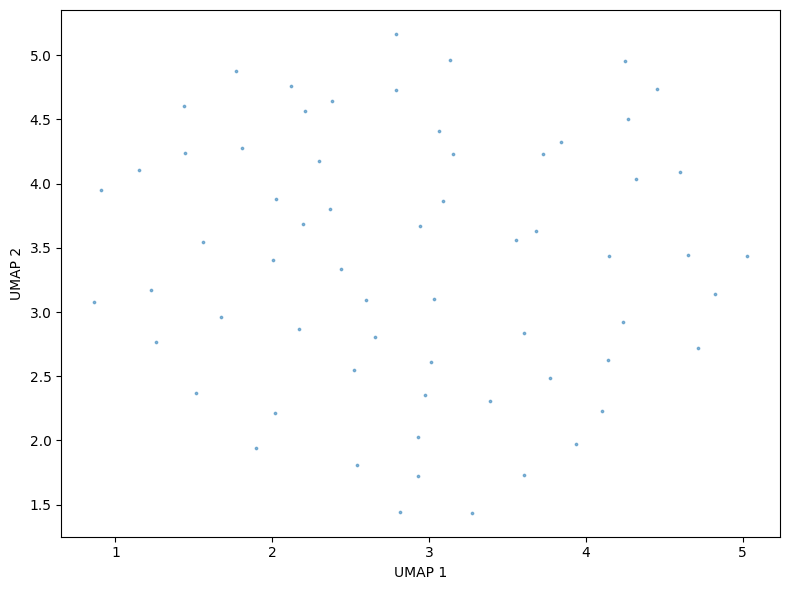

In [16]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

# embeddings: torch.Tensor with shape [n, 768]
embedding_array = embeddings.detach().float().cpu().numpy()

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

coordinates = reducer.fit_transform(embedding_array)  # shape: [n, 2]

plt.figure(figsize=(8, 6))
plt.scatter(coordinates[:, 0], coordinates[:, 1], s=3, alpha=0.5)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [1]:
import argparse
from collections import Counter
import json
from pathlib import Path

from canonicalize.common import CANONICAL_PARQUET_SCHEMA_VERSION, canonical_parquet_schema


def merge_datasets(
    parquet_file_paths: list[Path],
    output_path: str | Path,
    arrow_batch_size: int = 50_000,
    overwrite: bool = False,
) -> dict[str, object]:
    
    if arrow_batch_size < 1:
        raise ValueError("arrow_batch_size must be at least 1")

    try:
        import pyarrow.parquet as parquet
        from pyarrow import Table
    except ModuleNotFoundError as error:
        raise ModuleNotFoundError(
            "analyzing canonical Parquet requires pyarrow; install it in the "
            "environment used for analysis"
        ) from error

    output = Path(output_path)
    if output.exists() and not overwrite:
        raise FileExistsError(
            f"refusing to overwrite {output}; pass --overwrite to replace it"
        )
    output.parent.mkdir(parents=True, exist_ok=True)

    parquet_files = [parquet.ParquetFile(path) for path in parquet_file_paths]

    reference_schema = parquet_files[0].schema_arrow

    for path, parquet_file in zip(parquet_file_paths, parquet_files):
        if not parquet_file.schema_arrow.equals(reference_schema):
            raise ValueError(f"schema diverso in {path}")

    metadata = {
        b"canonical_schema_version": CANONICAL_PARQUET_SCHEMA_VERSION.encode(),
        b"source_datasets": json.dumps( 
            [f"{path.parent.name}/{path.name}" for path in parquet_file_paths] 
            ).encode("utf-8"),
        b"merger_script": str(Path(__file__).resolve()),
    }

    output_schema = reference_schema.with_metadata(metadata)

    temporary_path = output_path.with_name(
        f".{output_path.name}.partial"
    )

    writer = parquet.ParquetWriter(
        temporary_path,
        output_schema,
        compression="zstd",
    )

    try:
        for parquet_file in parquet_files:
            for batch in parquet_file.iter_batches(
                batch_size=50_000
            ):
                table = Table.from_batches(
                    [batch],
                    schema=output_schema,
                )
                writer.write_table(
                    table,
                    row_group_size=batch.num_rows,
                )
    finally:
        writer.close()

    temporary_path.replace(output_path)


In [4]:
DATASET_ROOT = Path("/mnt/filesystem-test/nmr/datasets")

parquet_file_paths: list[Path] = [DATASET_ROOT / "mst_nmr" / "test.parquet", DATASET_ROOT / "nmrexp" / "test.parquet", DATASET_ROOT / "nmrtrans" / "test.parquet"]
output_path: str | Path = DATASET_ROOT / "merged/merged_test.parquet"
arrow_batch_size: int = 50_000
overwrite: bool = True

# merge_datasets(
#     parquet_file_paths=parquet_file_paths,
#     output_path=output_path,
#     arrow_batch_size=arrow_batch_size,
#     overwrite=overwrite,
# )

In [ ]:
from pyarrow import parquet
from data.schema import ensure_record
from data.validation import IncompatibleRecordError, validate_canonical_record
from collections import Counter

output_path: str | Path = DATASET_ROOT / "merged/merged_test.parquet"
parquet_file = parquet.ParquetFile(output_path)

metadata = parquet_file.schema_arrow.metadata

for key, value in metadata.items():
    key = key.decode("utf-8")
    value = value.decode("utf-8")
    print(f"{key}: {value}")

canonical_schema_version: 1
source_datasets: ["mst_nmr/test.parquet", "nmrexp/test.parquet", "nmrtrans/test.parquet"]
merger_script: /mnt/filesystem-test/nmr/scripts/postprocess/merge_datasets.py


In [42]:
column_name = "smiles_canonical"
values = parquet_file.read(columns=[column_name])[column_name].to_pylist()

print(len(values))

def get_canonical(smile):
    try:
        mol_obj = Chem.MolFromSmiles(smile)
        if mol_obj is None:
            raise ValueError(f"Invalid SMILES string: {smile}")
        
        return Chem.MolToSmiles(mol_obj, canonical = True, isomericSmiles=True)

    except ValueError as e:
        print(f"Error occurred while processing SMILES string: {e}")
        return None

smiles = [get_canonical(record) for record in values]

208431


In [ ]:
from pathlib import Path

import pandas as pd
from rdkit import Chem


def molecular_identifiers(smiles):
    """Restituisce identificatori RDKit senza standardizzare sali/tautomeri."""
    if not isinstance(smiles, str) or not smiles.strip():
        return {
            "canonical_smiles_rdkit": None,
            "full_inchikey": None,
            "connectivity_inchikey": None,
        }

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {
            "canonical_smiles_rdkit": None,
            "full_inchikey": None,
            "connectivity_inchikey": None,
        }

    canonical_smiles = Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True,
    )

    try:
        full_inchikey = Chem.MolToInchiKey(mol)
    except Exception:
        full_inchikey = None

    connectivity_inchikey = (
        full_inchikey.split("-")[0]
        if full_inchikey
        else None
    )

    return {
        "canonical_smiles_rdkit": canonical_smiles,
        "full_inchikey": full_inchikey,
        "connectivity_inchikey": connectivity_inchikey,
    }


def add_molecular_identifiers(frame, smiles_column):
    result = frame.copy().reset_index(drop=True)
    result["_audit_row"] = range(len(result))

    identifiers = pd.DataFrame(
        [molecular_identifiers(smiles) for smiles in result[smiles_column]],
    )

    return pd.concat([result, identifiers], axis=1)


def find_smiles_column(frame):
    columns_by_lower_name = {
        str(column).strip().casefold(): column
        for column in frame.columns
    }

    # "Drug" è la colonna SMILES nei file TDC.
    candidates = [
        "drug",
        "smiles",
        "smiles_canonical",
        "canonical_smiles",
        "canonical smiles",
    ]

    for candidate in candidates:
        if candidate in columns_by_lower_name:
            return columns_by_lower_name[candidate]

    raise KeyError(
        "Non trovo una colonna SMILES. Colonne disponibili: "
        f"{list(frame.columns)}"
    )


def read_dataset(path):
    if path.suffix == ".csv":
        return pd.read_csv(path)
    if path.suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    if path.suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Formato non supportato: {path}")


def overlap_report(merged_test, admet, dataset_name):
    merged_full = set(merged_test["full_inchikey"].dropna())
    admet_full = set(admet["full_inchikey"].dropna())

    merged_connectivity = set(merged_test["connectivity_inchikey"].dropna())
    admet_connectivity = set(admet["connectivity_inchikey"].dropna())

    exact_matches = merged_full & admet_full
    connectivity_matches = merged_connectivity & admet_connectivity

    # Gruppi con stessa connettività ma senza un match full InChIKey.
    exact_match_connectivity = {
        key.split("-")[0]
        for key in exact_matches
    }
    connectivity_only = connectivity_matches - exact_match_connectivity

    return {
        "dataset": dataset_name,
        "admet_rows": len(admet),
        "admet_invalid_smiles": int(admet["full_inchikey"].isna().sum()),
        "admet_unique_molecules": len(admet_full),
        "admet_duplicate_rows": int(
            admet["full_inchikey"].notna().sum() - len(admet_full)
        ),
        "exact_overlap_unique_molecules": len(exact_matches),
        "exact_overlap_admet_percent": round(
            100 * len(exact_matches) / len(admet_full), 2
        ) if admet_full else 0.0,
        "merged_test_records_matched": int(
            merged_test["full_inchikey"].isin(exact_matches).sum()
        ),
        "connectivity_overlap_groups": len(connectivity_matches),
        "connectivity_only_groups": len(connectivity_only),
    }

In [46]:
from collections import Counter

count = Counter(smiles)

has_duplicates = [count > 1 for count in count.values()]
print(sum(has_duplicates))  # True

1057


In [17]:
file_metadata = [parquet_file.schema_arrow.metadata for parquet_file in [
    parquet.ParquetFile(path) for path in parquet_file_paths]
    ]
file_metadata

[{b'canonical_schema_version': b'1',
  b'source_dataset': b'NMRPeak-MST-NMR',
  b'converter': b'convert_mst_nmr.py'},
 {b'canonical_schema_version': b'1',
  b'source_dataset': b'NMRPeak-NMRexp',
  b'converter': b'convert_nmrexp.py'},
 {b'canonical_schema_version': b'1',
  b'source_dataset': b'NMRTrans-NMRSpec',
  b'converter': b'convert_nmrtrans.py'}]

In [18]:
columns = [
 'record_id',
 'source',
 'smiles',
 'smiles_canonical',
#  'molecular_formula',
#  'nmr_frequency',
#  'nmr_solvent',
#  'atoms',
#  'coordinates',
 'h_nmr_peaks',
 'c_nmr_peaks'
 ]

In [41]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [31]:
arrow_batch = next(iter(parquet_file.iter_batches(batch_size=50, columns=columns,)))
arrow_batch_df = [ensure_record(row) for row in arrow_batch.to_pylist()]
arrow_batch_df[0]

CanonicalRecord(record_id='nmrpeak-mst-nmr:test:0', source='NMRPeak-MST-NMR', smiles='CSc1ccc(C(=O)CC(=O)CF)cc1', smiles_canonical='CSc1ccc(C(=O)CC(=O)CF)cc1', molecular_formula=None, nmr_frequency=None, nmr_solvent=None, atoms=None, coordinates=None, h_nmr_peaks=(ProtonPeak(shift=7.835369162342482, integration=2, multiplicity_raw='m', multiplicity='m', j_values=(), range_min=7.806741282447256, range_max=7.865072679944704, range_half_span=0.029165698748723656, equivalence_class=None, member_shifts=None), ProtonPeak(shift=7.344616844478618, integration=2, multiplicity_raw='m', multiplicity='m', j_values=(), range_min=7.314942122409231, range_max=7.373247064418529, range_half_span=0.02915247100464935, equivalence_class=None, member_shifts=None), ProtonPeak(shift=5.289113595242149, integration=1, multiplicity_raw='s', multiplicity='s', j_values=(), range_min=5.271118202044093, range_max=5.307108988440206, range_half_span=0.01799539319805632, equivalence_class=None, member_shifts=None), Pr

In [ ]:
arrow_batch = next(iter(parquet_file.iter_batches(batch_size=50, columns=columns,)))
arrow_batch_df = [ensure_record(row) for row in arrow_batch.to_pylist()]
arrow_batch_df[0]

mol_obj = Chem.MolFromSmiles(arrow_batch_df[0].smiles)

atom_list = [atom.GetSymbol() for atom in mol_obj.GetAtoms()]
molecular_formula = rdMolDescriptors.CalcMolFormula(mol_obj)
canonical_smile = Chem.MolToSmiles(mol_obj, canonical=True)

In [9]:
for arrow_batch in parquet_file.iter_batches(
    batch_size=arrow_batch_size,
    columns=columns,
    use_threads=True,
):
    rows += arrow_batch.num_rows

    first_row = rows - arrow_batch.num_rows + 1
    for row_offset, value in enumerate(arrow_batch.to_pylist()):
        row_number = first_row + row_offset
        try:
            record = ensure_record(value)
            validation = validate_canonical_record(record)
        except (TypeError, ValueError) as error:
            raise ValueError(
                f"could not decode row {row_number} of {output_path}: {error}"
            ) from error
        if not validation.is_valid:
            raise ValueError(
                f"invalid canonical row {row_number} of {output_path}: "
                f"{IncompatibleRecordError(validation.record_id, validation.issues)}"
            )

        

NameError: name 'columns' is not defined